# 🌡️ 11-模拟退火与禁忌搜索

> 目标：掌握两条「**单点 + 记忆**」的元启发式主线——模拟退火 SA（接受劣解逃出局部最优）与
> 禁忌搜索 TS（记忆最近动作避免回头）。TSP 上手，面试考原理与调参。也顺带对比无记忆的随机重启。

## §0 局部搜索的困境与两条出路

**局部搜索（局部最优陷阱）**：从解出发，只朝「改进方向」移动 → 停在最近的局部最优，与全局最优可能相去甚远。

**出路 1（SA）**：**允许暂时变差**——以概率接受劣解，温度高时概率大（全局探索），温度低时概率小（局部收敛）。
**出路 2（TS）**：**记住最近动作**——最近做过的移动进禁忌表，短期内禁止回头，强制探索新区域。

**邻域**：TSP 用 **2-opt**（反转一段）或 **swap**（交换两城市）。邻域是启发式的设计自由度，见 §2。

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ---------- TSP 实例（N=20 城市，让局部最优陷阱足够明显） ----------
N = 20
rng = np.random.default_rng(5)
cities = rng.random((N, 2)) * 10
dist = np.sqrt(((cities[:, None, :] - cities[None, :, :]) ** 2).sum(-1))   # 距离矩阵 d[i,j]

def tour_len(order):
    # 封闭环长：相邻城市距离之和 + 最后回到起点
    return sum(dist[order[i], order[(i + 1) % N]] for i in range(N))

def random_tour(r):
    return r.permutation(N).tolist()

# ================= 基线：随机重启局部搜索（无记忆） =================
# 思想：反复随机初始化 + 贪心 2-opt 改进，各跑一次，取最好。
# 它没有「记忆」：每次重启都从零开始，容易反复掉进同一个局部最优。
def random_restart(restarts=25, steps=100, seed=0):
    r = np.random.default_rng(seed)
    best = np.inf
    for _ in range(restarts):
        cur = random_tour(r); L = tour_len(cur)
        for _ in range(steps):
            i, j = sorted(r.integers(0, N, size=2).tolist())   # 随机取一段 [i,j]
            nxt = cur[:i] + cur[i:j + 1][::-1] + cur[j + 1:]   # 2-opt：反转该段
            nL = tour_len(nxt)
            if nL < L:                                          # 只接受改进
                cur = nxt; L = nL
        best = min(best, L)
    return best

rr_len = random_restart()
print('随机重启局部搜索最优环长: %.2f' % rr_len)

随机重启局部搜索最优环长: 49.37


模拟退火最优环长: 41.23


禁忌搜索最优环长: 40.70
随机重启 49.37 | SA 41.23 | TS 40.70


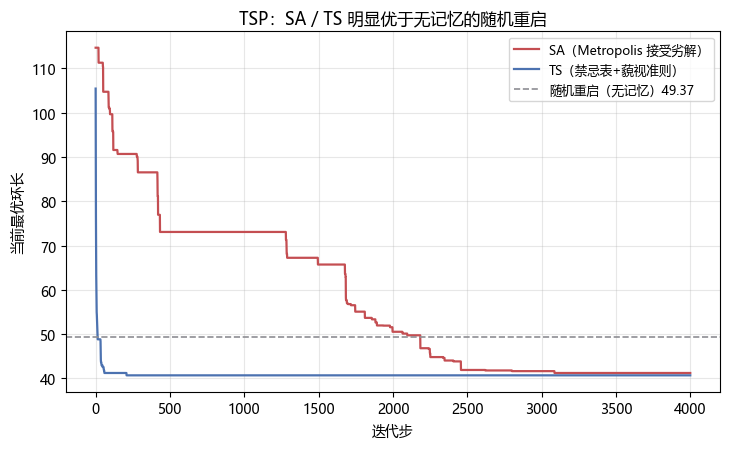

In [2]:
# ================= 手写模拟退火（SA） =================
# 核心：Metropolis 准则——当前解 x，邻居 y，代价差 Δ = f(y)-f(x)：
#   若 Δ < 0（更好）→ 一定接受
#   若 Δ ≥ 0（更差）→ 以概率 exp(-Δ/T) 接受（T 越大越敢接受坏解）
# 温度 T 从 T0 按 T ← T * alpha 几何降温：
#   高温段：几乎什么都接受 → 全局乱逛（逃出局部最优）
#   低温段：只接受改进 → 精细收敛（模拟淬火成晶体）
def sa_tsp(T0=50, alpha=0.998, iters=4000, seed=1):
    r = np.random.default_rng(seed)
    cur = random_tour(r); L = tour_len(cur)
    best = L; best_tour = cur[:]
    T = T0
    hist = []
    for _ in range(iters):
        i, j = sorted(r.integers(0, N, size=2).tolist())
        nxt = cur[:i] + cur[i:j + 1][::-1] + cur[j + 1:]     # 2-opt 邻居
        nL = tour_len(nxt)
        delta = nL - L
        # Metropolis 判定：改进必收；恶化按概率收（exp(-Δ/T) ∈ (0,1)，Δ 越大越难收）
        if delta < 0 or r.random() < np.exp(-delta / T):
            cur = nxt; L = nL
            if L < best:                                      # 全程记录最优（降温后期可能回升）
                best = L; best_tour = cur[:]
        T *= alpha                                            # 几何降温
        hist.append(best)
    return best, best_tour, np.array(hist)

sa_len, sa_tour, sa_hist = sa_tsp()
print('模拟退火最优环长: %.2f' % sa_len)

# ================= 手写禁忌搜索（TS） =================
# 核心三件套：
#   1) 禁忌表：记录最近做过/撤销的动作（swap 城市对），禁止立刻重做 → 防止在局部最优来回震荡
#   2) 藐视准则（aspiration）：若禁忌动作能刷新全局最优，破例允许（好到值得破戒）
#   3) 邻域选择：每步考察整个 swap 邻域，选「非禁忌中最好」的动作执行
def ts_tsp(tabu_len=18, iters=4000, seed=2):
    r = np.random.default_rng(seed)
    cur = random_tour(r); L = tour_len(cur)
    best = L; best_tour = cur[:]
    # 禁忌矩阵：tabu[a,b] = 最早允许再次交换 (a,b) 的代数（0 = 不禁忌）
    tabu = np.zeros((N, N), int)
    hist = []
    for it in range(iters):
        best_move = None; best_nL = np.inf
        for a in range(N):                                    # 枚举 swap 邻域（全部城市对）
            for c in range(a + 1, N):
                if a == c: continue
                nxt = cur[:]; nxt[a], nxt[c] = nxt[c], nxt[a]   # 交换两城市位置
                nL = tour_len(nxt)
                # 禁忌判断：该城市对在禁忌期内，且不能刷新全局最优（藐视准则）→ 跳过
                if tabu[a, c] > it and nL >= best - 1e-9:
                    continue
                if nL < best_nL:                              # 选当前邻域里最好的合法动作
                    best_nL = nL; best_move = (a, c, nxt)
        if best_move is None:                                 # 邻域全被禁忌 → 随机一步（防死锁）
            a, c = sorted(r.integers(0, N, size=2).tolist())
            nxt = cur[:]; nxt[a], nxt[c] = nxt[c], nxt[a]
            cur = nxt; L = tour_len(nxt)
        else:
            a, c, cur = best_move; L = best_nL
            tabu[a, c] = it + tabu_len                        # 动作进禁忌表（到期自动解禁）
            tabu[c, a] = it + tabu_len
        if L < best:                                          # 更新全局最优
            best = L; best_tour = cur[:]
        hist.append(best)
    return best, best_tour, np.array(hist)

ts_len, ts_tour, ts_hist = ts_tsp()
print('禁忌搜索最优环长: %.2f' % ts_len)

print('随机重启 %.2f | SA %.2f | TS %.2f' % (rr_len, sa_len, ts_len))
assert sa_len < rr_len and ts_len < rr_len, 'SA/TS 应明显优于无记忆的随机重启'

# ========== 图：收敛曲线对比 ==========
fig, ax = plt.subplots(figsize=(7.4, 4.6))
ax.plot(sa_hist, lw=1.6, color='#C44E52', label='SA（Metropolis 接受劣解）')
ax.plot(ts_hist, lw=1.6, color='#4C72B0', label='TS（禁忌表+藐视准则）')
ax.axhline(rr_len, color='#8E8E93', ls='--', lw=1.2, label='随机重启（无记忆）%.2f' % rr_len)
ax.set_xlabel('迭代步'); ax.set_ylabel('当前最优环长')
ax.set_title('TSP：SA / TS 明显优于无记忆的随机重启', fontsize=12)
ax.legend(fontsize=9); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

## §1 调参地图与原理深挖

**SA 三参数**：初始温度 $T_0$（足够大到能接受大部分劣解）、降温率 $\alpha$（0.9~0.999，越小越快越粗）、
迭代数（与 $T_0,\alpha$ 匹配，总步数 ≈ $\ln(T_f/T_0)/\ln\alpha$）。
**Metropolis 的直觉**：$\exp(-\Delta/T)$——$\Delta$ 大（很坏）几乎不接受，$T$ 大（高温）什么都接受。
数学上 SA 在理想降温计划下以概率 1 收敛到全局最优（Geman & Geman 1984，理论保证但不实用）。

**TS 三件套**：禁忌表长度 $L$（太短防不住回环，太长限制搜索，本讲 18，约 N）、
禁忌对象（TSP 常用**城市对**，也可用完整解/动作）、藐视准则（何时破例）。
**TS 变体**：随机化 TS、频率记忆（长期禁忌低频动作）、路径重连（path relinking）。

**邻域设计是灵魂**：2-opt 一次改 2 条边，swap 一次换 2 个位置——邻域大小、可改进幅度决定收敛速度与质量。

## §2 面试追问与自测

1. Metropolis 准则的公式与直觉？为什么高温敢接受坏解？
2. SA 参数怎么调？降温太快/太慢分别有什么后果？
3. 禁忌表记什么？禁忌长度太短/太长？藐视准则何时用？
4. SA vs TS vs 随机重启的本质区别？（概率接受 vs 强制记忆 vs 无记忆）
5. 2-opt 是什么？为什么它很少破坏环结构？

**自测清单**
- [ ] 手写 Metropolis 判定（一行 if 条件）
- [ ] 手写禁忌表更新 + 邻域扫描 + 藐视准则
- [ ] 说出 SA/TS 各自防止「困在局部最优」的机制
- [ ] 复现本讲：SA/TS 均优于随机重启（断言已内置）

> 💡 下节预告：群体智能——12 粒子群与蚁群算法。